In [6]:
import os
import zipfile


zip_path = "/content/drive/MyDrive/Colab Notebooks/UODD.zip"


extract_dir = "/content/uodd_dataset"

if not os.path.exists(extract_dir):
    print("The underwater data set is being extracted...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction completed!")
else:
    print("The folder already exists.")

Sualtı veri seti çıkarılıyor...
Çıkarma işlemi tamamlandı!


In [7]:

!pip install ultralytics -q
from ultralytics import YOLO


data_yaml_path = f"{extract_dir}/aquarium_pretrain/data.yaml"

# loading yolo26
model = YOLO("yolo26n.pt")

print("YOLO26 Object Detection training is about to begin...")

# saving to the drive
results = model.train(
    data=data_yaml_path,
    epochs=20,
    imgsz=640,       # The standard resolution is 640p.
    batch=16,        # batch 16 is safer for ram.
    project="/content/drive/MyDrive/Sualti_Projesi",
    name="yolo26_egitim"
)

YOLO26 ile Nesne Tespiti eğitimi başlıyor...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/uodd_dataset/aquarium_pretrain/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_egitim, nbs=64, nms=False, opset=None, opt

İşte YOLO26 modelinin Confusion Matrix'i:


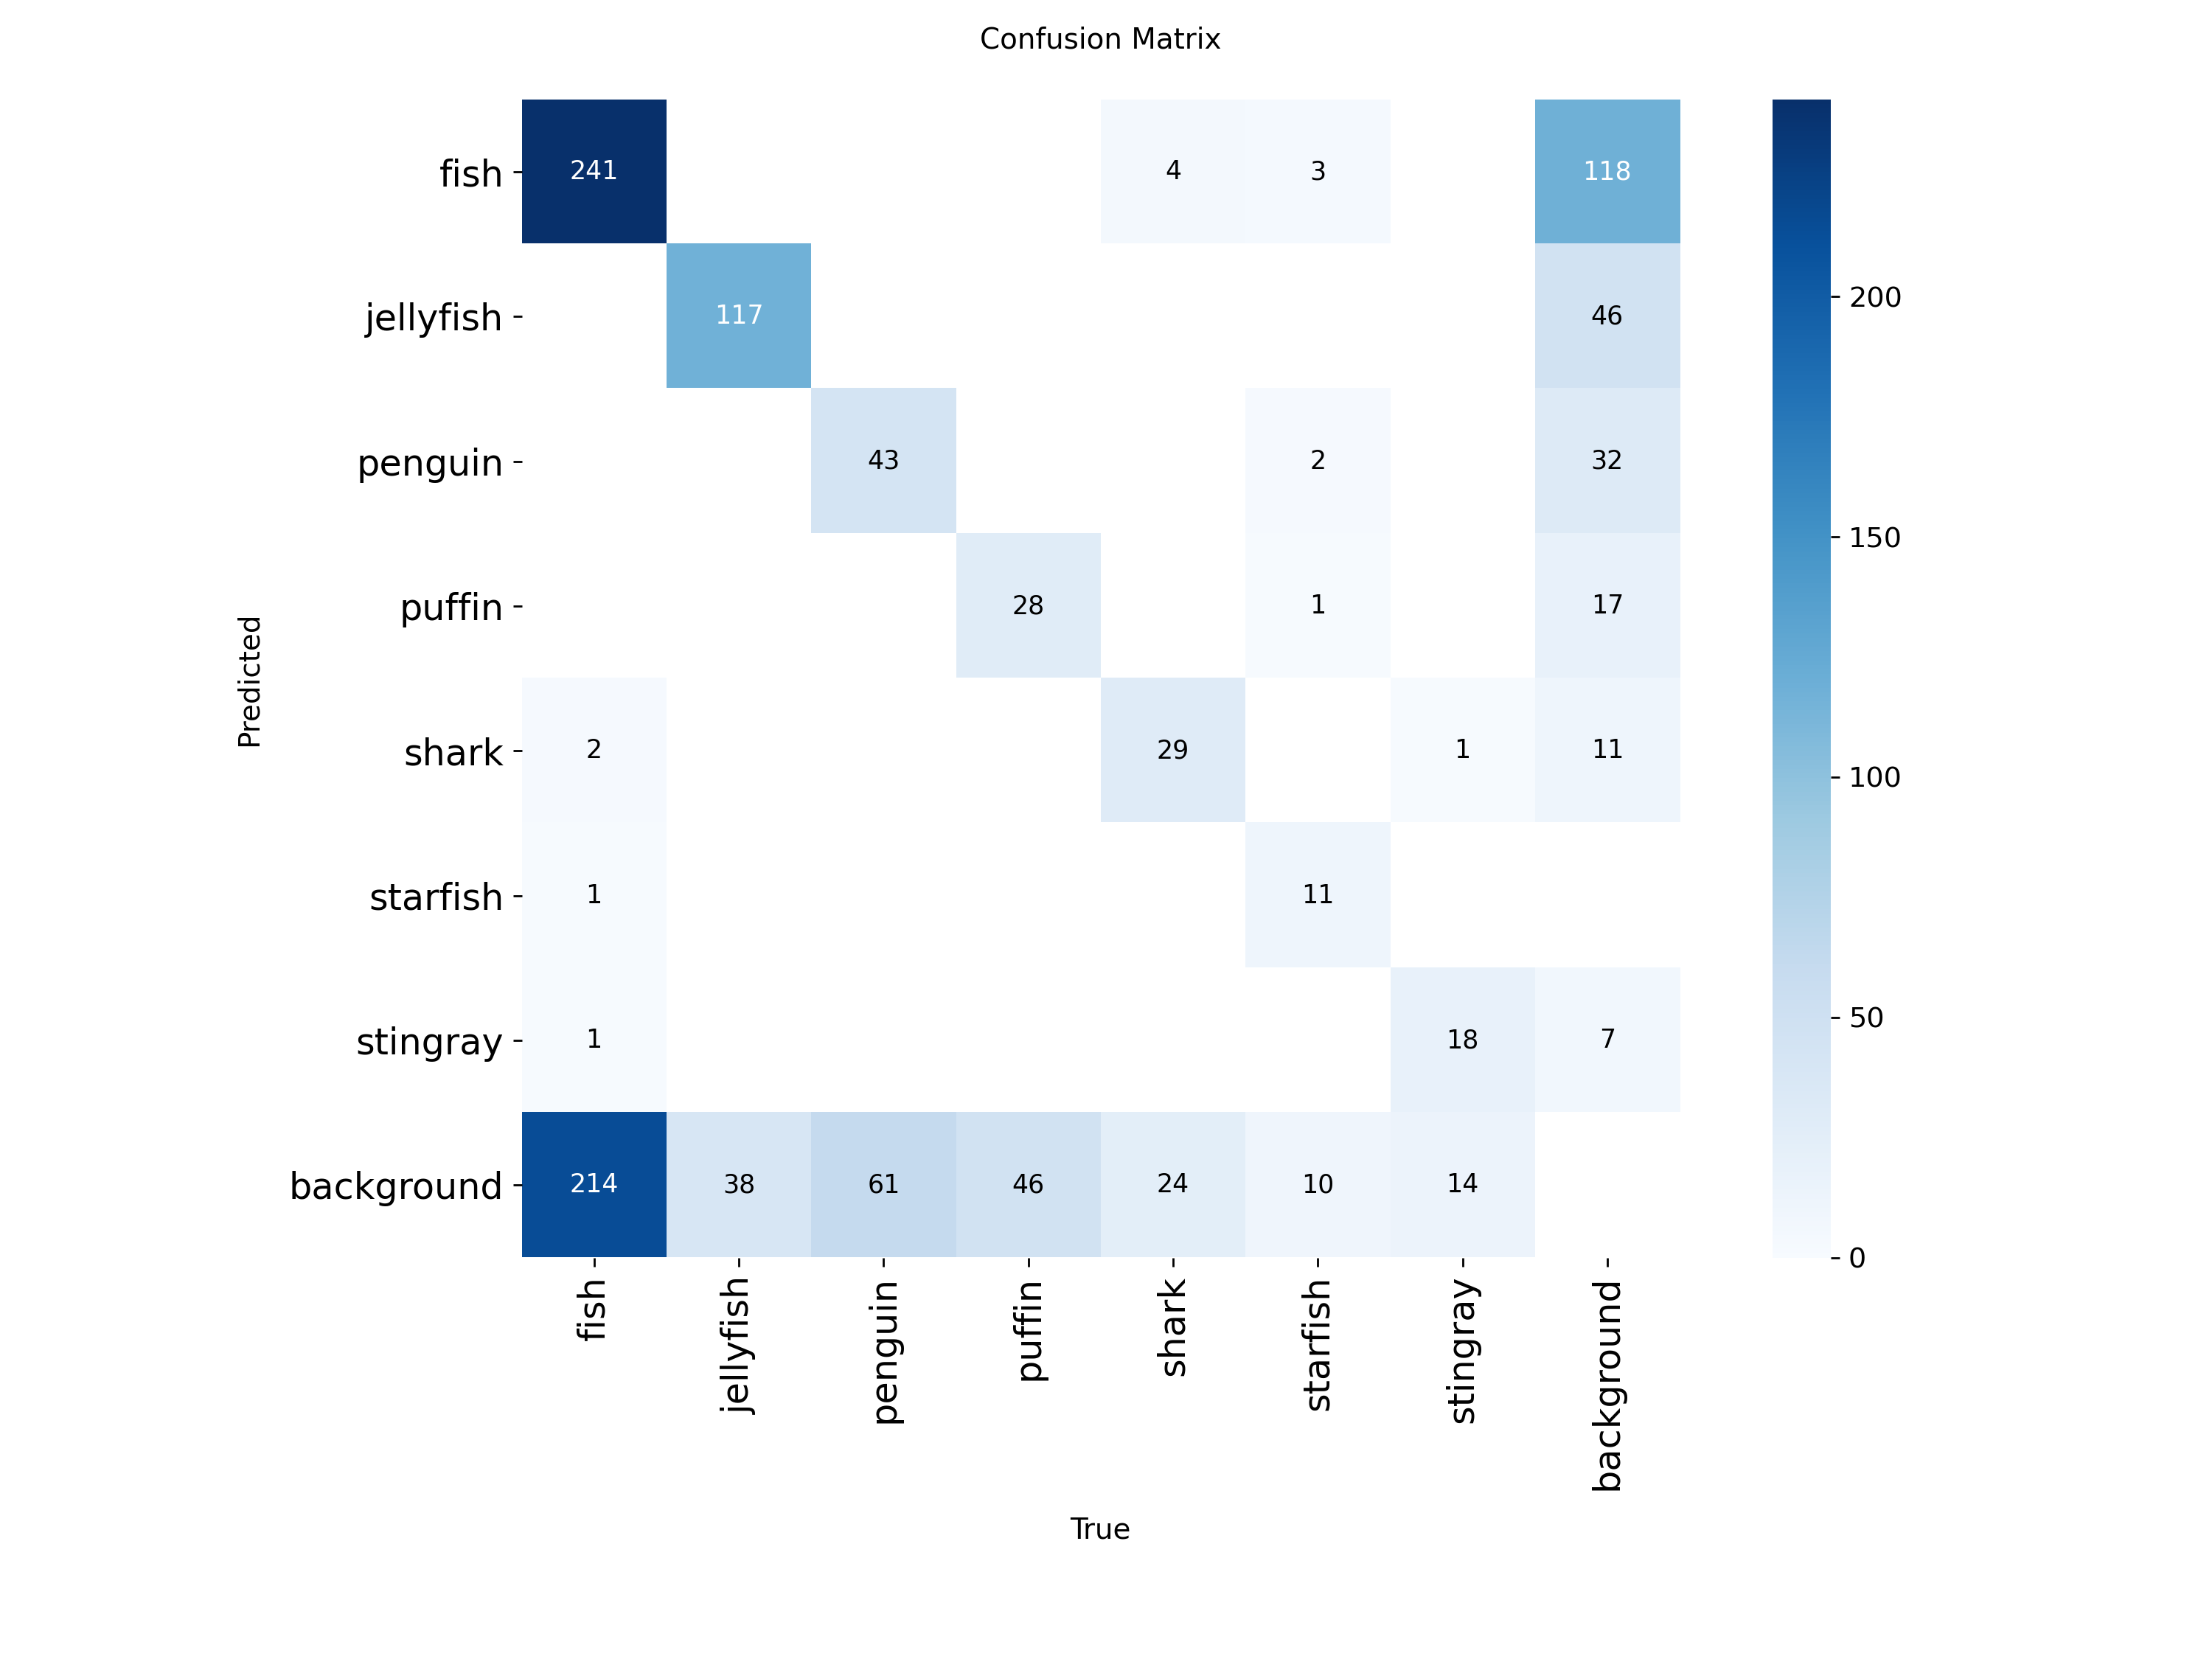

In [8]:
from IPython.display import Image, display

# new project adress
matrix_yolu = "/content/drive/MyDrive/Sualti_Projesi/yolo26_egitim/confusion_matrix.png"

if os.path.exists(matrix_yolu):
    print("Here is the Confusion Matrix of the YOLO26 model:")
    display(Image(filename=matrix_yolu, width=800))
else:
    print("Matrix not found. Check the Drive folder.")


image 1/1 /content/uodd_dataset/aquarium_pretrain/test/images/IMG_8343_jpg.rf.2d88000497d74d72aedc118b125a0c07.jpg: 480x640 4 fishs, 12.5ms
Speed: 3.5ms preprocess, 12.5ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)


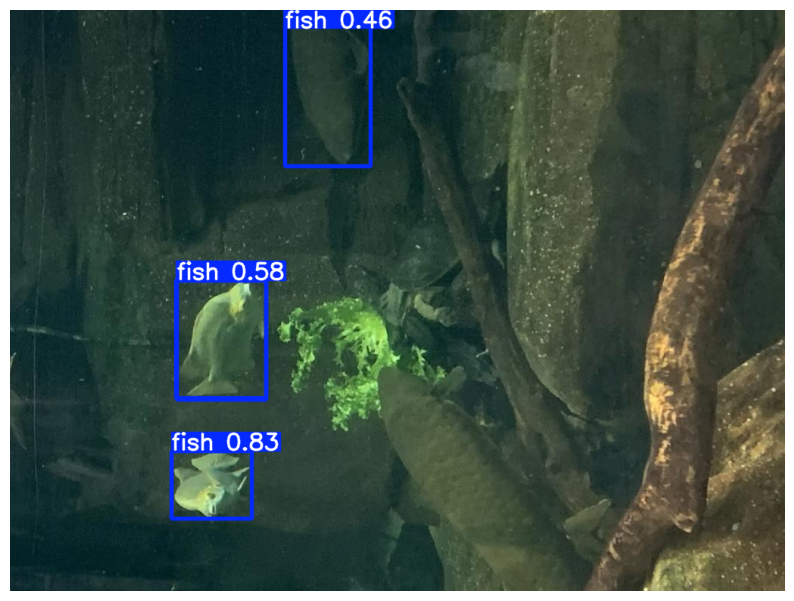

In [16]:
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

#  loading best model
en_iyi_model_yolu = "/content/drive/MyDrive/Sualti_Projesi/yolo26_egitim/weights/best.pt"
model = YOLO(en_iyi_model_yolu)


test_resimleri = glob.glob("/content/uodd_dataset/aquarium_pretrain/test/images/*.jpg")

if len(test_resimleri) > 0:
    # we can try different test images for test.
    test_resmi = test_resimleri[5]



    #  Prediction process (we set conf=0.15 so that the model is a bit bolder and draws a box)
    sonuclar = model.predict(source=test_resmi, conf=0.15)

    #  Plotting predictions onto the image (YOLO's own plotting method)
    cizimli_resim = sonuclar[0].plot()

    # converting the OpenCV color format (BGR) to the Matplotlib format (RGB).
    cizimli_resim_rgb = cv2.cvtColor(cizimli_resim, cv2.COLOR_BGR2RGB)

    # 5. Smooth and adjustable screen printing.
    plt.figure(figsize=(10, 8)) # (10, 8) boyutları ekrana tam ve kibar oturur
    plt.imshow(cizimli_resim_rgb)
    plt.axis('off')
    plt.show()

    # If the model found nothing, provide information.
    if len(sonuclar[0].boxes) == 0:
        print("Note: The model could not find any fish or other living creature in this image.")
        print("You can try other images by changing the 'test_images[0]' part in the code to 'test_images[1]' or [2].")

else:
    print("No images were found in the test folder.")